# 08 - Surface-Confined CV Analysis

This notebook analyzes a surface-confined scan-rate series imported from an eCAT Excel workbook. The workbook was generated separately from deterministic eCAT simulation objects, so the tutorial exercises a normal data-import workflow and does not require an optional simulation backend.

## Import eCAT And Set Paths

The checked-in workbook contains five CVs, one per scan rate, plus a manifest with the metadata required for round-trip reconstruction.

In [1]:
from copy import deepcopy
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
ROOT = ROOT.parent
WORKBOOK = (
    ROOT / 'examples' / 'data' / 'surface_coverage_cv'
    / 'surface_confined_cv_series.xlsx'
)

import ecat as e


## Import The Surface Series

`get_data_from_excel()` reconstructs each workbook block as a normal eCAT CV. The quickstart therefore matches the workflow for an experimentally collected surface series that has been exported through `save_data(..., format='xlsx')`.

In [2]:
surface_cvs = e.get_data_from_excel(WORKBOOK, {'print': False})
surface_cvs = e.sort(surface_cvs, 'scan rate', {'print': False})

assert len(surface_cvs) == 5
e.show(surface_cvs)


[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Scan Window: [-0.45, 0.25], Segments: 2


,Scan Rate
[0],25 mV/s
[1],50 mV/s
[2],100 mV/s
[3],200 mV/s
[4],500 mV/s


## Inspect Workbook Provenance

The fixture represents a reversible one-electron `E*` couple with known coverage. Values are stored in V, A, and s; eCAT rescales them only for display.

In [3]:
manifest = pd.read_excel(WORKBOOK, sheet_name='manifest')
display(manifest[['Name', 'class', 'Scan Rate', 'Electrode Area', 'Temperature']])
print('Expected coverage: 3e-10 mol/cm^2')
print('Expected loading:  3e-11 mol')


,Name,class,Scan Rate,Electrode Area,Temperature
0,surface_Estar_0.025Vs,cv,25 mV/s,0.1,298.15
1,surface_Estar_0.05Vs,cv,50 mV/s,0.1,298.15
2,surface_Estar_0.1Vs,cv,100 mV/s,0.1,298.15
3,surface_Estar_0.2Vs,cv,200 mV/s,0.1,298.15
4,surface_Estar_0.5Vs,cv,500 mV/s,0.1,298.15


Expected coverage: 3e-10 mol/cm^2
Expected loading:  3e-11 mol


## Plot The Imported CVs

For a reversible surface-confined wave, peak current scales with scan rate rather than the square root of scan rate. The overlay makes that proportional growth visible.

<Axes: title={'center': 'Imported Surface-Confined E* Series'}, xlabel='Potential (V)', ylabel='Current (μA)'>

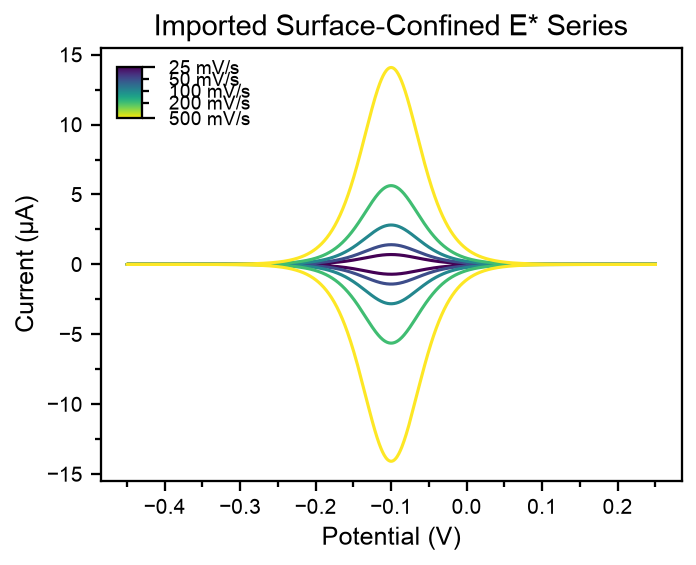

In [4]:
e.multiplot(surface_cvs, {
    'print': False,
    'title': 'Imported Surface-Confined E* Series',
    'gradient by': 'scan rate',
    'legend mode': 'colorbar',
    'colorbar tick labels': 'all',
})


## Surface Reversibility

Surface-confined data require `phase='surface'` explicitly. This path does not use Sevcik diffusion, Nicholson solution kinetics, or a solution-phase $k^0$ in cm/s. It evaluates peak separation, physical branch consistency, and current-ratio evidence.

Parameter,Symbol,Value
Phase,,surface
Electron Count,n,1.000000
Temperature,T,298.1 K
Diffusion Coefficient,D,Unavailable
Electrode Area,S,0.1 cm2
Scan Rates,ν,0.025 to 0.5 V/s
Segments,,"[1, 2]"
Agreement Tolerance,,0.25
Current Ratio Tolerance,,0.1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Assessment,Conclusion,Evidence
Electron Transfer,reversible,peak separation is within the effective zero-separation tolerance and ip is linear in scan rate
Chemical Reversibility,chemically reversible over observed timescale,"all 5 tangent-corrected |ip,a/ip,c| ratios are within tolerance of unity (range 1 to 1; maximum deviation from unity is 2.762e-05; current-ratio tolerance is 0.1)"
Electron-Transfer Rate,unresolved,k0 unresolved: the scan-rate series does not contain a sufficient Laviron high-separation region.


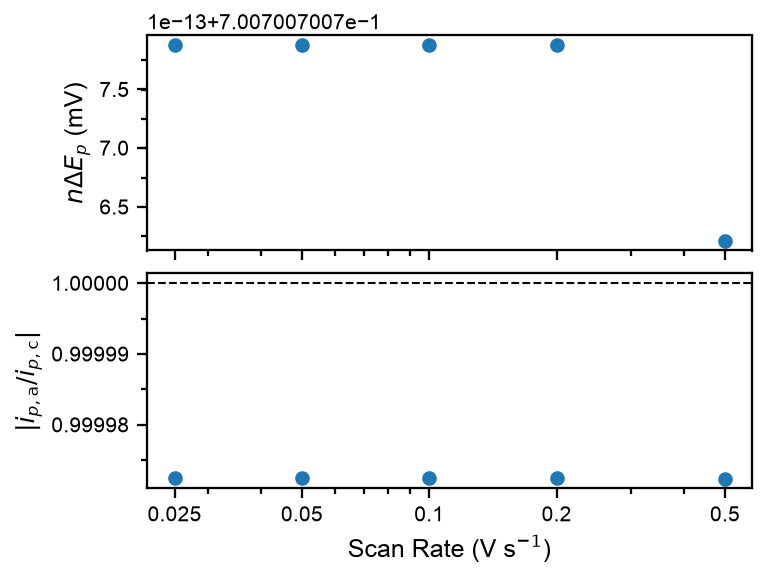

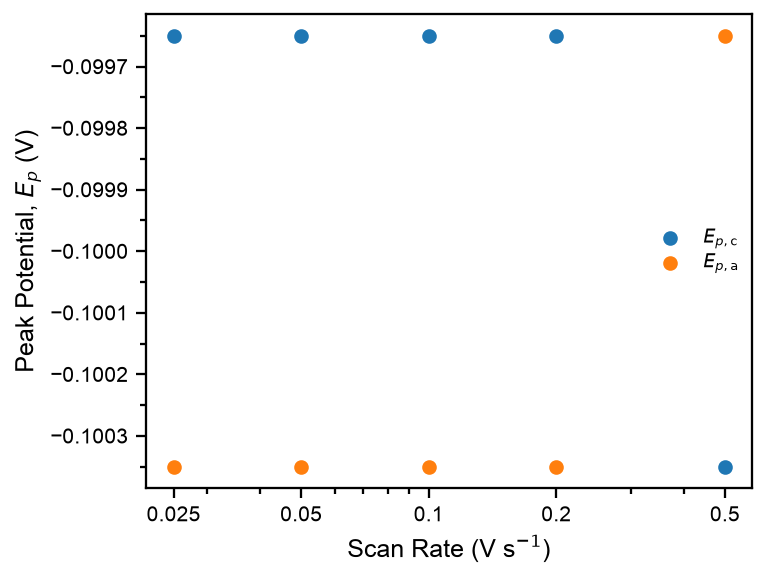

In [5]:
surface_reversibility = e.reversibility_analysis(
    surface_cvs,
    {
        'phase': 'surface',
        'segments': [1, 2],
        'guess potential': [-0.10, -0.10],
        'num electrons': 1,
        'plot': True,
        'plot all': True,
        'print': True,
    },
)


## Surface Coverage And Loading

`surface_coverage_analysis()` reports two independent estimates. The slope method uses $i_p$ versus scan rate; the charge method integrates the tangent-corrected wave using $dt=dE/v$. With electrode area, both surface coverage and total loading are reported.

Parameter,Symbol,Value
Electron Count,n,1.000000
Temperature,T,298.1 K
Electrode Area,S,0.1 cm2
Agreement Tolerance,,0.250000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

branch,segment,slope / A s V-1,intercept / A,R2,Γslope / mol cm-2,Loading slope / mol,fit points
cathodic,1,0.000028,0.000000,1.000000,0.000000,0.000000,5
anodic,2,0.000028,0.000000,1.000000,0.000000,0.000000,5


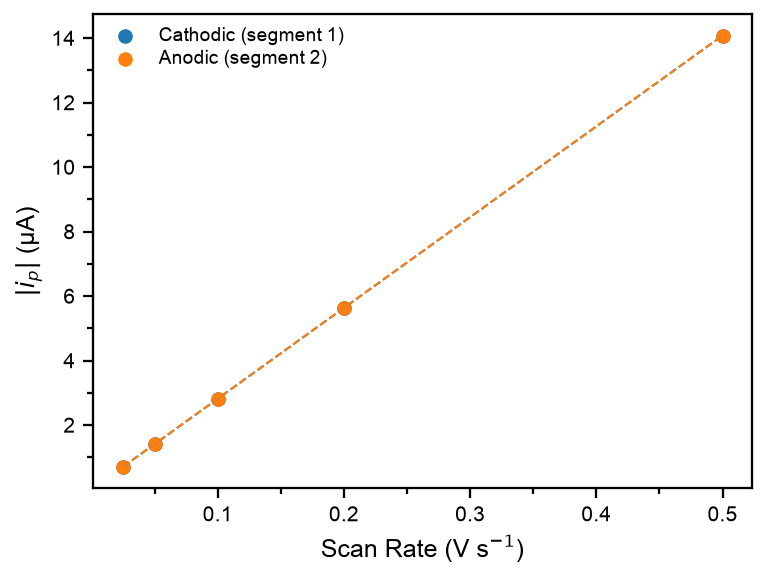

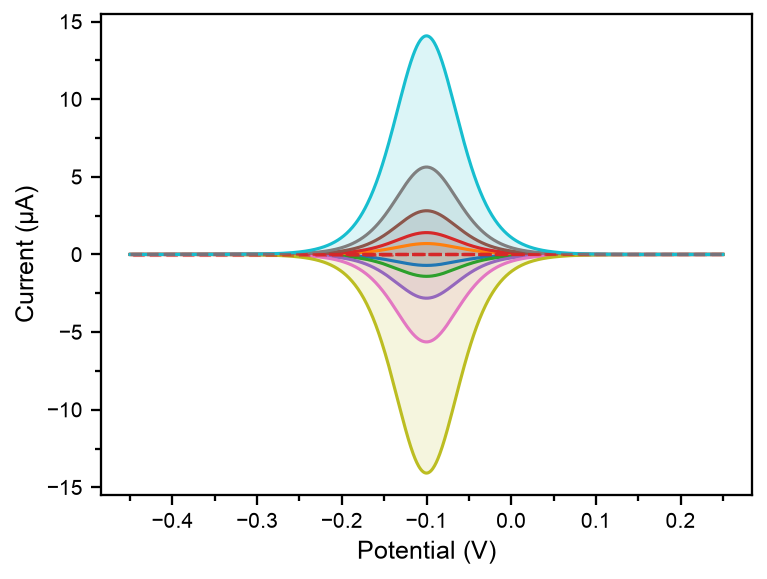

In [6]:
surface_coverage = e.surface_coverage_analysis(
    surface_cvs,
    {
        'segments': [1, 2],
        'guess potential': [-0.10, -0.10],
        'electrode area': 0.10,
        'integration range': 'auto',
        'plot': True,
        'plot all': True,
        'print': True,
    },
)


## Check Expected Recovery

The fixture has known inputs, so the notebook checks that both methods recover the expected coverage and loading within the documented numerical tolerances.

In [7]:
expected_coverage = 3e-10
expected_loading = 3e-11
recovery = pd.DataFrame([
    {
        'Method': 'Peak-current slope',
        'Quantity': 'Coverage',
        'Expected': expected_coverage,
        'Recovered': surface_coverage.summary['coverage slope / mol cm^-2'],
        'Unit': 'mol cm^-2',
    },
    {
        'Method': 'Integrated charge',
        'Quantity': 'Coverage',
        'Expected': expected_coverage,
        'Recovered': surface_coverage.summary['coverage charge / mol cm^-2'],
        'Unit': 'mol cm^-2',
    },
    {
        'Method': 'Peak-current slope',
        'Quantity': 'Loading',
        'Expected': expected_loading,
        'Recovered': surface_coverage.summary['loading slope / mol'],
        'Unit': 'mol',
    },
    {
        'Method': 'Integrated charge',
        'Quantity': 'Loading',
        'Expected': expected_loading,
        'Recovered': surface_coverage.summary['loading charge / mol'],
        'Unit': 'mol',
    },
])
display(recovery)

assert np.isclose(recovery.loc[0, 'Recovered'], expected_coverage, rtol=0.01)
assert np.isclose(recovery.loc[1, 'Recovered'], expected_coverage, rtol=0.02)
assert np.isclose(recovery.loc[2, 'Recovered'], expected_loading, rtol=0.01)
assert np.isclose(recovery.loc[3, 'Recovered'], expected_loading, rtol=0.02)


,Method,Quantity,Expected,Recovered,Unit
0,Peak-current slope,Coverage,3.000000e-10,2.999484e-10,mol cm^-2
1,Integrated charge,Coverage,3.000000e-10,2.984034e-10,mol cm^-2
2,Peak-current slope,Loading,3.000000e-11,2.999484e-11,mol
3,Integrated charge,Loading,3.000000e-11,2.984034e-11,mol


## Loading Without Electrode Area

If area is unavailable, integrated charge and the peak-current slope still resolve the total electroactive loading. Surface coverage remains unavailable rather than being silently inferred.

In [8]:
no_area_cvs = deepcopy(surface_cvs)
for cv_obj in no_area_cvs:
    cv_obj.electrode_area = None

loading_only = e.surface_coverage_analysis(
    no_area_cvs,
    {
        'segments': [1, 2],
        'guess potential': [-0.10, -0.10],
        'integration range': 'auto',
        'plot': False,
        'print': True,
    },
)
assert np.isnan(loading_only.summary['coverage slope / mol cm^-2'])
assert np.isfinite(loading_only.summary['loading slope / mol'])


Parameter,Symbol,Value
Electron Count,n,1.000000
Temperature,T,298.1 K
Electrode Area,S,Unavailable
Agreement Tolerance,,0.250000


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

branch,segment,slope / A s V-1,intercept / A,R2,Γslope / mol cm-2,Loading slope / mol,fit points
cathodic,1,0.000028,0.000000,1.000000,nan,0.000000,5
anodic,2,0.000028,0.000000,1.000000,nan,0.000000,5


## Inspect Available Options

The agreement tolerance controls the warning threshold between slope and charge estimates and can be changed globally through eCAT defaults.

In [9]:
e.describe_options('surface_coverage_analysis')

,Category,Option,Default,Type,Description
0,Data/input,temperature,None,float or None,"Temperature in K. If omitted, uses CV metadata and then the established 298.15 K fallback."
1,Selection/filtering,exact potential,None,float or list[float] or None,"Exact potential for current extraction; when provided it bypasses peak-location auto-selection. In complex CV analyses, the plural alias 'exact potentials' accepts per-CV values."
2,Selection/filtering,fit indices,None,object or None,"Row/position-based fit selection. Use [start, stop] with Python-style exclusive stop, None for an open-ended side, a boolean mask, explicit indices, multiple windows for one disconnected fit, or a dict for named fits."
3,Selection/filtering,guess potential,None,float or list[float] or list[list[float]] or None,"Initial potential guess for automatic peak or wave selection. In complex CV analyses, the plural alias 'guess potentials' accepts per-CV values; scalar guesses keep running-guess behavior where supported."
4,Selection/filtering,plot segment,None,int or None,Segment to emphasize or plot.
5,Selection/filtering,plot segments,None,list[int] or int or None,Segments to emphasize or plot.
6,Selection/filtering,segment,None,int or None,CV segment to analyze.
7,Selection/filtering,segments,None,list[int] or None,One or more CV segments to analyze.
8,Units/normalization,electrode area,None,float or None,"Electrode area in cm^2. If omitted, total electroactive loading remains available but areal coverage is unavailable."
9,Units/normalization,x unit,auto,str or None,'auto' auto scales from the selected CV data and stored units.


## Next Step

Notebook 09 returns to bulk-solution workflows for normalization, catalytic analysis, and general model fitting.